# Value at Risk and Conditional Value at Risk

**Value at Risk (VaR)** answers: *what is the worst loss we expect over a given horizon, with a given confidence?* At 95 % confidence, VaR is the 5th percentile of the return distribution — 95 % of returns sit above it, 5 % below.

**Conditional Value at Risk (CVaR)**, also called Expected Shortfall, is the *mean* of the returns at or below the VaR threshold. CVaR is a coherent risk measure (it satisfies subadditivity); VaR is not.

**What is being measured here.** `get_var` and `get_cvar` pool every column's daily returns into a single sample before taking the percentile. The number they return therefore describes a bad day for a *typical asset in the universe*, not a bad day for a weighted portfolio — reweighting the assets would not move it. That makes it a clean way to compare asset classes against each other, which is what section 4 does.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.ticker import PercentFormatter
from scipy import stats
from sklearn.neighbors import KernelDensity

from portfolio.data import DataIngestion, compute_returns
from portfolio.models.risk import get_cvar, get_var

ingestion = DataIngestion()
all_prices = ingestion.get_all_prices()
all_returns = compute_returns(all_prices)

## EDA of Returns.

VaR and CVaR are functions of the empirical return distribution, so the first thing to inspect is its shape. The two diagnostics that matter most are **skewness** (asymmetry) and **kurtosis** (tail heaviness). A normal distribution has skew 0 and excess kurtosis 0; financial returns typically have negative skew and positive excess kurtosis.

In [2]:
flat = all_returns.stack().to_numpy()
flat = flat[np.isfinite(flat)]

summary = pd.Series({
    "observations": len(flat),
    "mean": flat.mean(),
    "std": flat.std(ddof=1),
    "min": flat.min(),
    "5th percentile": np.percentile(flat, 5),
    "median": np.median(flat),
    "95th percentile": np.percentile(flat, 95),
    "max": flat.max(),
    "skewness": stats.skew(flat),
    "excess kurtosis": stats.kurtosis(flat),
})
summary

observations       30396.000000
mean                   0.000630
std                    0.027000
min                   -0.333225
5th percentile        -0.037177
median                 0.000279
95th percentile        0.037160
max                    0.612198
skewness               1.079592
excess kurtosis       26.447733
dtype: float64

## Computing VaR and CVaR

`get_var(prices, confidence)` and `get_cvar(prices, confidence)` both take **prices**, not returns — they call `pct_change` internally. The default confidence is 95 % (`DEFAULT_CONFIG.default_confidence`); `get_risk_metrics` computes every level in `DEFAULT_CONFIG.confidence_levels` in a single pass.

Both are signed, so a negative number is a loss.

In [4]:
var_95 = get_var(all_prices, confidence=0.95)
cvar_95 = get_cvar(all_prices, confidence=0.95)

print(f"VaR  (95%): {var_95:.6f}")
print(f"CVaR (95%): {cvar_95:.6f}")

VaR  (95%): -0.037177
CVaR (95%): -0.062860


### Visualising VaR / CVaR on the return distribution

The bins at or below VaR are drawn in red: they are the worst 5 % of trading days. VaR is the boundary of that region, and CVaR is its mean — which is why CVaR always sits further left. The inset zooms into the red tail, where the averaging actually happens; on the main axes those bars are only a few pixels tall.

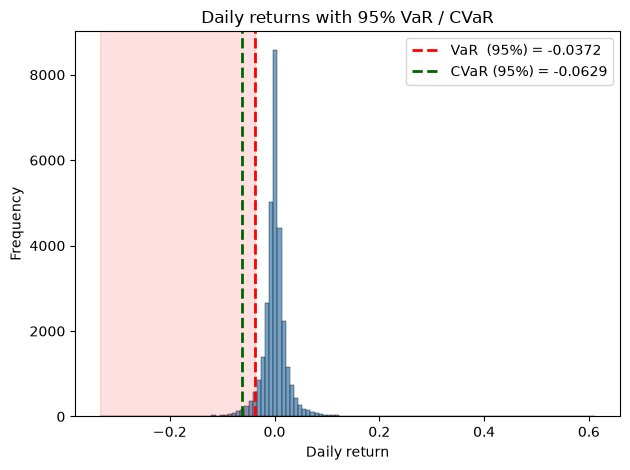

In [6]:
fig, ax = plt.subplots()
sns.histplot(flat, bins=120, color="steelblue", ax=ax)
ax.axvline(var_95, color="red", linestyle="--", linewidth=2,
           label=f"VaR  (95%) = {var_95:.4f}")
ax.axvline(cvar_95, color="darkgreen", linestyle="--", linewidth=2,
           label=f"CVaR (95%) = {cvar_95:.4f}")
ax.axvspan(flat.min(), var_95, alpha=0.12, color="red")
ax.set_xlabel("Daily return")
ax.set_ylabel("Frequency")
ax.set_title("Daily returns with 95% VaR / CVaR")
ax.legend()
fig.tight_layout()
plt.show()